<a href="https://colab.research.google.com/github/wwvvlllttggiitt/ADII/blob/main/Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Подготовка

In [418]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.1)

In [419]:
df = pd.read_csv('/content/dataset (2).csv')
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.head()


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


2. Первичный анализ данных

In [420]:
df.info()

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [421]:
df.isna().sum()


,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


3. Логическая структура БД

In [422]:
artist_col = None
for c in ["artist", "artists", "track_artist"]:
    if c in df.columns:
        artist_col = c
        break

4. EDA-анализ данных

In [423]:
target = 'popularity'

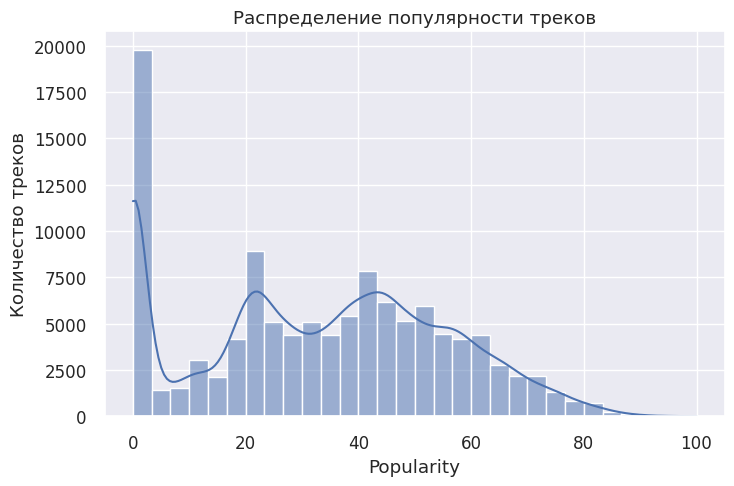

In [424]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df[target], bins=30, kde=True)
plt.title('Распределение популярности треков')
plt.xlabel('Popularity')
plt.ylabel('Количество треков')
plt.show()

In [425]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['popularity', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')

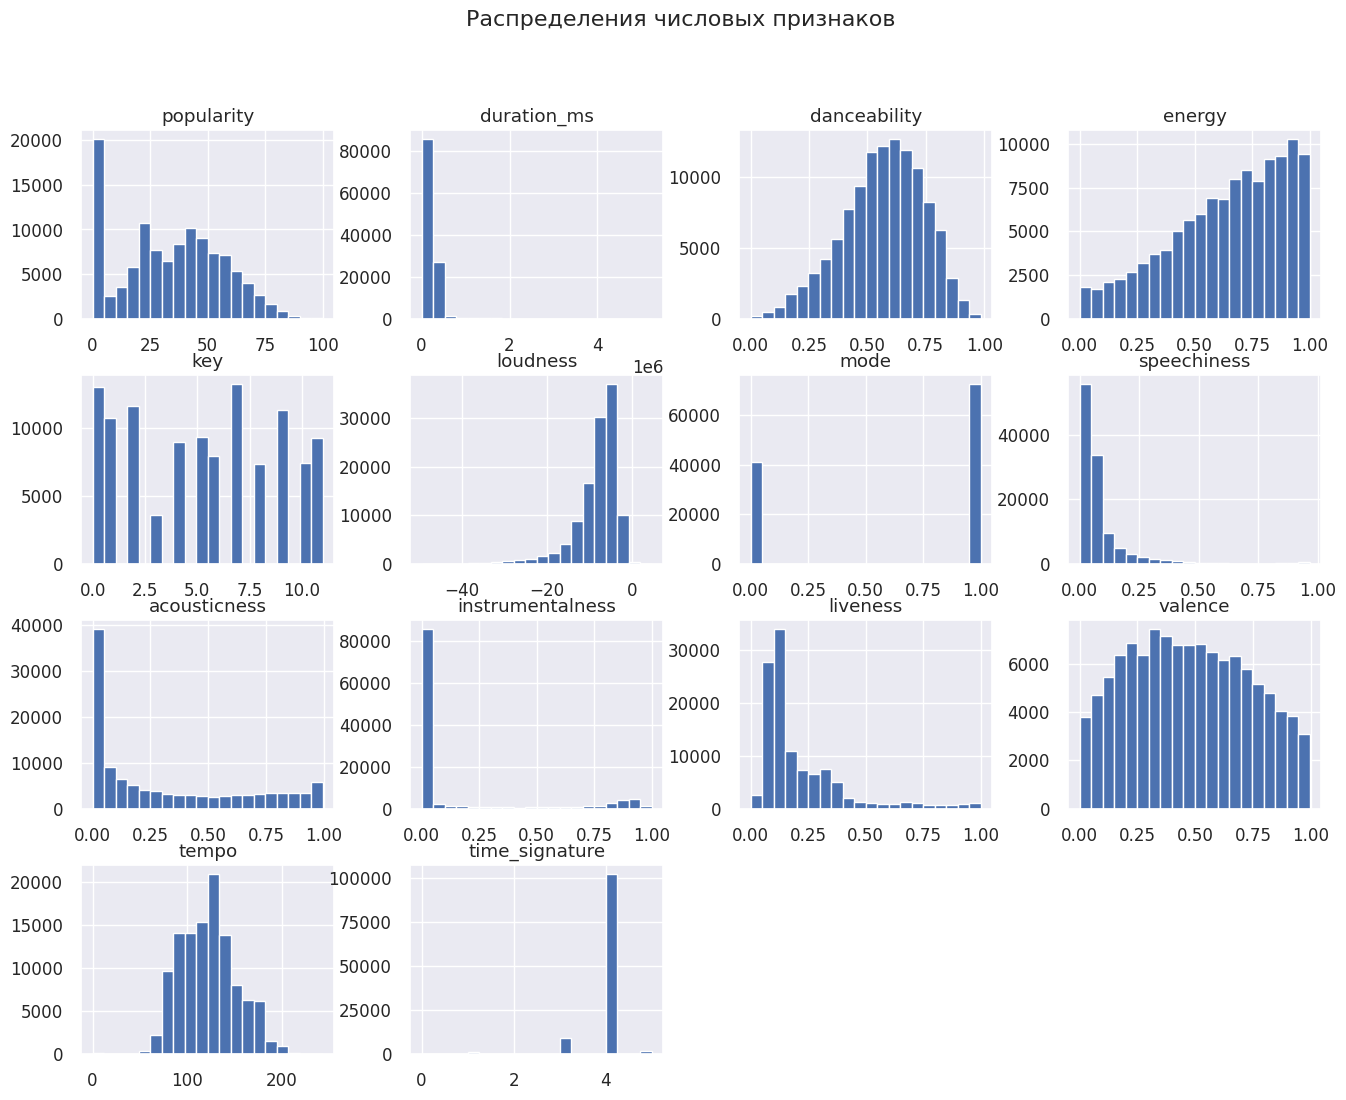

In [426]:
df[numeric_cols].hist(figsize=(16,12), bins=20)
plt.suptitle('Распределения числовых признаков', fontsize=16)
plt.show()

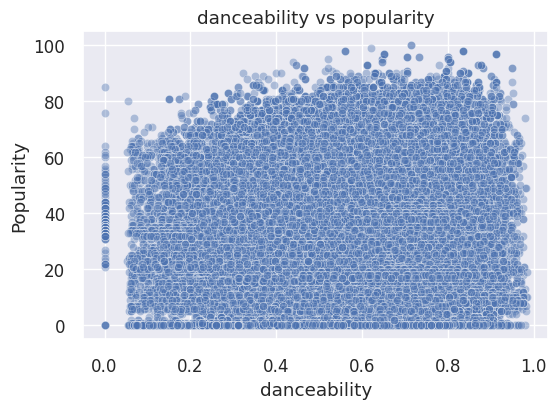

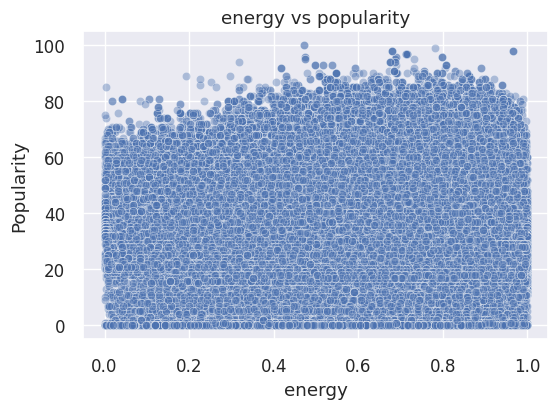

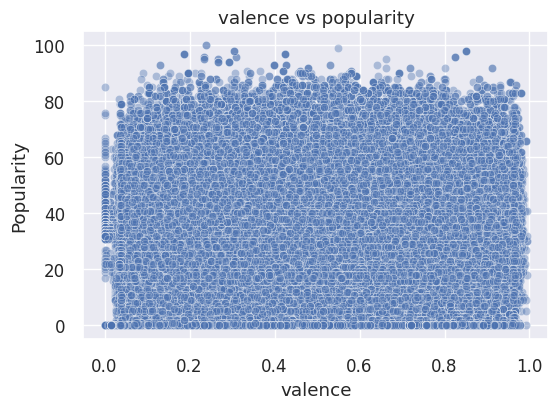

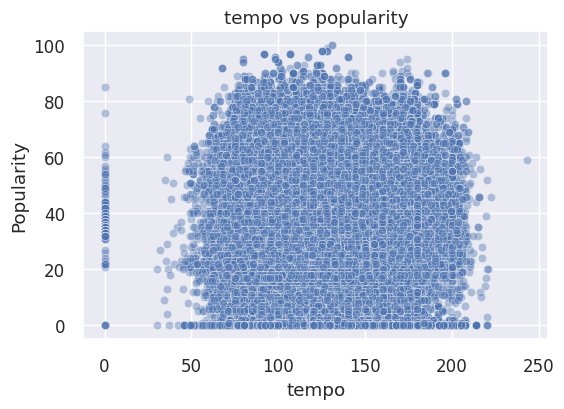

In [427]:
features_to_plot = ['danceability', 'energy', 'valence', 'tempo']

for col in features_to_plot:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df[target], alpha=0.4)
        plt.title(f'{col} vs popularity')
        plt.xlabel(col)
        plt.ylabel('Popularity')
        plt.show()

In [428]:
corr_target = df[numeric_cols].corr()[target].sort_values(ascending=False)
corr_target

,popularity
popularity,1.000000
loudness,0.050423
danceability,0.035448
time_signature,0.031073
tempo,0.013205
energy,0.001056
key,-0.003853
liveness,-0.005387
duration_ms,-0.007101
mode,-0.013931


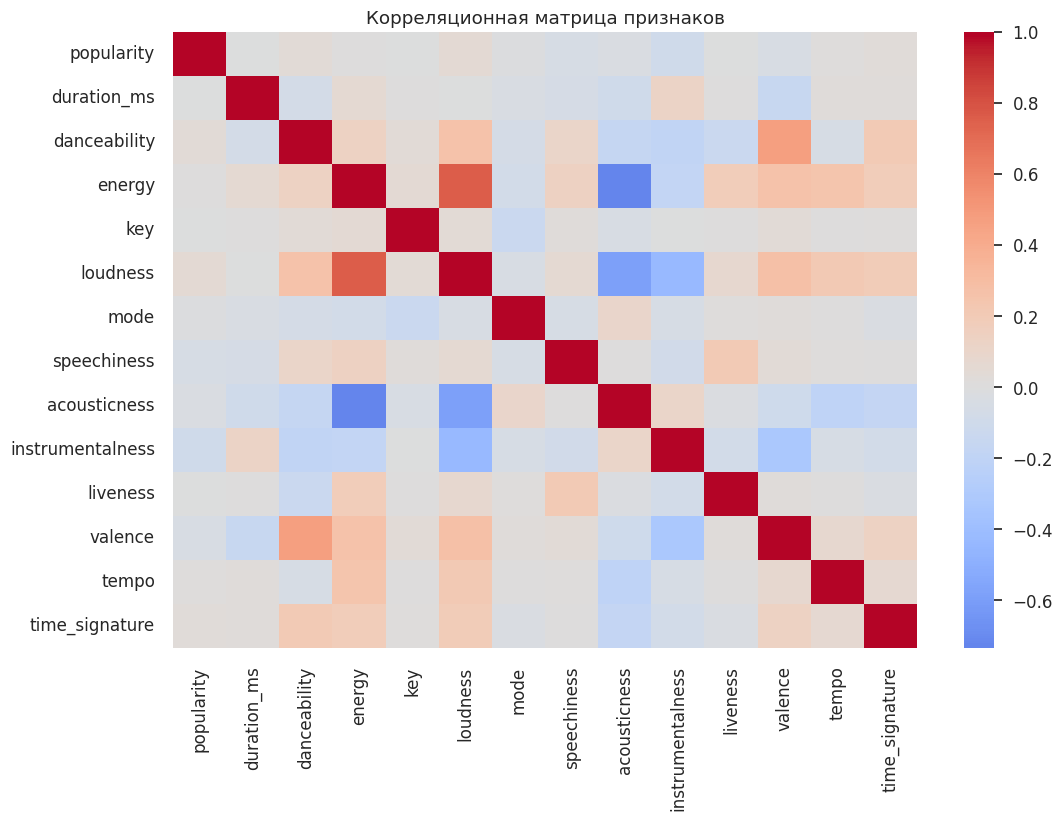

In [429]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0)
plt.title('Корреляционная матрица признаков')
plt.show()

5. Feature engineering



In [430]:
df_fe = df.copy()

In [431]:
df_fe['mood_score'] = (df_fe['valence'] + df_fe['energy']) / 2

In [432]:
df_fe['dance_energy_ratio'] = df_fe['danceability'] / (df_fe['energy'] + 0.01)

In [433]:
df_fe['loudness_norm'] = (
    df_fe['loudness'] - df_fe['loudness'].min()
) / (
    df_fe['loudness'].max() - df_fe['loudness'].min()
)

In [434]:
df_fe['fast_tempo'] = (df_fe['tempo'] > df_fe['tempo'].median()).astype(int)

In [435]:
new_features = ['mood_score', 'dance_energy_ratio', 'loudness_norm', 'fast_tempo']

df_fe[new_features + ['popularity']].corr()['popularity'].sort_values(ascending=False)

,popularity
popularity,1.000000
loudness_norm,0.050423
fast_tempo,0.007168
dance_energy_ratio,-0.006536
mood_score,-0.025274


In [436]:
X = df_fe.select_dtypes(include=['int64', 'float64']).drop(columns=['popularity'])
y = df_fe['popularity']

In [437]:
X.shape, y.shape

((114000, 17), (114000,))

In [438]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [439]:
X_scaled.shape

(114000, 17)

In [440]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


6. Обучение нейронных сетей

In [441]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

rmse_lr, r2_lr

(21.978597241458196, 0.021119660111093674)

In [442]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5
r2_dt = r2_score(y_test, y_pred_dt)

rmse_dt, r2_dt

(20.54827528102454, 0.14438100921913766)

In [443]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor( n_estimators=50, random_state=42, n_jobs=-1 )

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

rmse_rf, r2_rf

(14.962064375676427, 0.5463585782878091)

In [444]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)

,0
acousticness,0.096584
duration_ms,0.092535
tempo,0.089156
speechiness,0.088777
danceability,0.079506
liveness,0.077652
valence,0.077254
instrumentalness,0.066600
mood_score,0.063110
dance_energy_ratio,0.062692


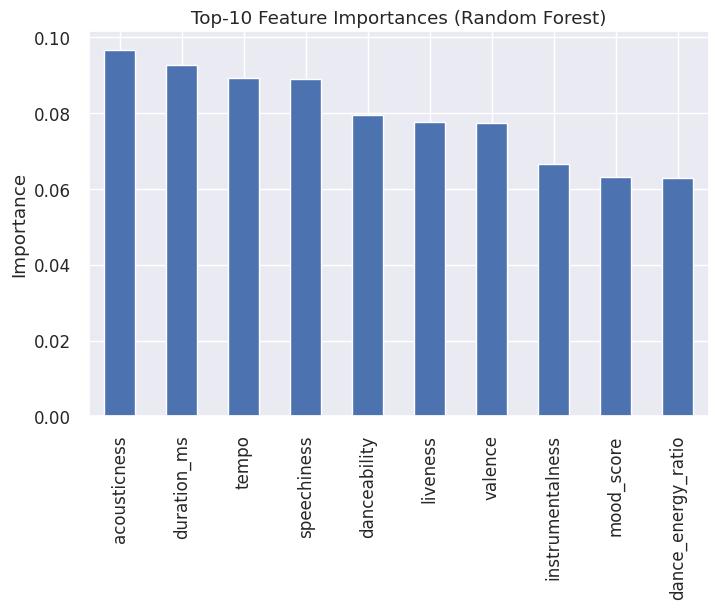

In [445]:
plt.figure(figsize=(8,5))
importances.head(10).plot(kind='bar')
plt.title('Top-10 Feature Importances (Random Forest)')
plt.ylabel('Importance')
plt.show()

In [446]:
!pip install catboost

7. Оценка качества моделей

In [447]:
from catboost import CatBoostRegressor

from sklearn.model_selection import RandomizedSearchCV
param_dist = {'depth': [4, 6, 8],
              'learning_rate': [0.01, 0.05, 0.1],
              'iterations': [200, 500, 1000]}
search = RandomizedSearchCV(cb, param_dist, n_iter=5, cv=3)
search.fit(X_train_scaled, y_train)
best_cb = search.best_estimator_

cb = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function='RMSE',
    verbose=False,
    random_seed=42
)

cb.fit(X_train, y_train)

y_pred_cb = cb.predict(X_test)

rmse_cb = mean_squared_error(y_test, y_pred_cb) ** 0.5
r2_cb = r2_score(y_test, y_pred_cb)

rmse_cb, r2_cb

(19.832763842855687, 0.20293058275012554)

In [448]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

rmse_mlp = mean_squared_error(y_test, y_pred_mlp) ** 0.5
r2_mlp = r2_score(y_test, y_pred_mlp)

rmse_mlp, r2_mlp

(22.982067045706177, -0.0703057027302092)

8. Feature importances

In [449]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'CatBoost',
        'Neural Network'
    ],
    'RMSE': [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_cb,
        rmse_mlp
    ],
    'R2': [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_cb,
        r2_mlp
    ]
})

results.sort_values(by='RMSE')

,Model,RMSE,R2
2,Random Forest,14.962064,0.546359
3,CatBoost,19.832764,0.202931
1,Decision Tree,20.548275,0.144381
0,Linear Regression,21.978597,0.021120
4,Neural Network,22.982067,-0.070306


9. Кросс-валидация

In [450]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
from catboost import CatBoostRegressor


kf = KFold(n_splits=5, shuffle=True, random_state=42)

model_cv = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function='RMSE',
    verbose=False,
    random_seed=42
)


neg_mse_scores = cross_val_score(
    model_cv,
    X_scaled,
    y,
    cv=kf,
    scoring='neg_mean_squared_error'
)

rmse_scores = np.sqrt(-neg_mse_scores)

rmse_scores

array([19.83505803, 19.94021593, 20.08256887, 19.78784602, 19.88582129])

In [451]:
rmse_mean = rmse_scores.mean()
rmse_std = rmse_scores.std()

rmse_mean, rmse_std

(np.float64(19.906302028552496), np.float64(0.101732143264608))